# PCA with scikit-learn
Full sklearn pipeline — `StandardScaler` + `PCA` on California Housing.
Model saved to `../Models/pca_sklearn.joblib`.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

raw      = fetch_california_housing(as_frame=True)
features = list(raw.feature_names)
X_raw    = raw.frame[features]
y        = raw.frame['MedHouseVal'].values

print(f"Shape: {X_raw.shape[0]:,} × {X_raw.shape[1]}")
X_raw.head(3)

Shape: 20,640 × 8


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24


## 2. Fit PCA Pipeline

`n_components=None` keeps all components — we inspect variance explained to decide
how many to keep, then refit with the chosen k.

In [2]:
pipeline_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=None, random_state=42))
])

pipeline_full.fit(X_raw)
pca_full = pipeline_full['pca']
p        = X_raw.shape[1]

ev_df = pd.DataFrame({
    'Eigenvalue':        pca_full.explained_variance_.round(4),
    'Explained Var (%)': (pca_full.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)':    (pca_full.explained_variance_ratio_.cumsum() * 100).round(2)
}, index=[f'PC{i+1}' for i in range(p)])
ev_df

,Eigenvalue,Explained Var (%),Cumulative (%)
PC1,2.0270,25.34,25.34
PC2,1.8814,23.52,48.85
PC3,1.2712,15.89,64.74
PC4,1.0311,12.89,77.63
PC5,1.0031,12.54,90.17
PC6,0.6594,8.24,98.41
PC7,0.0816,1.02,99.43
PC8,0.0456,0.57,100.00


## 3. Scree Plot + Cumulative Variance

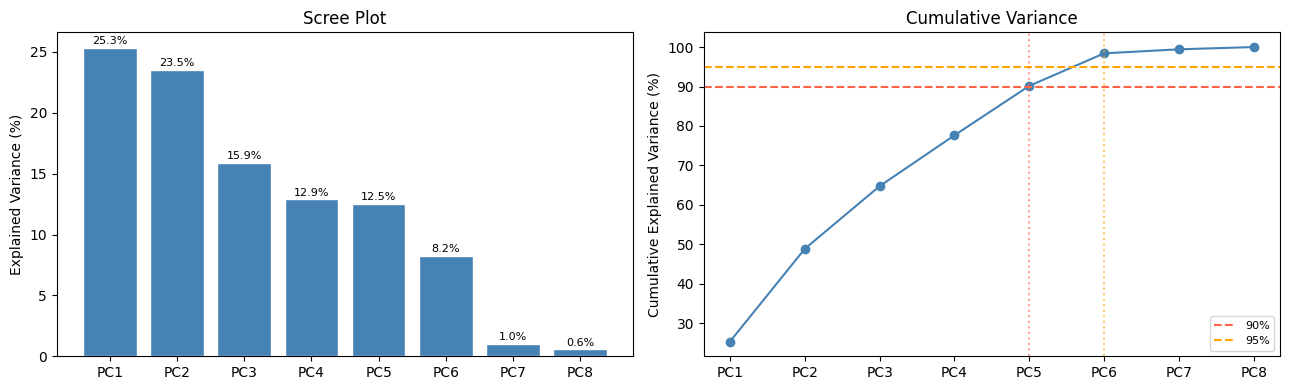

Components for 90% variance: 5
Components for 95% variance: 6


In [3]:
evr = pca_full.explained_variance_ratio_
cum = evr.cumsum()
pcs = [f'PC{i+1}' for i in range(p)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bars = ax1.bar(pcs, evr * 100, color='steelblue', edgecolor='white')
ax1.set_ylabel('Explained Variance (%)'); ax1.set_title('Scree Plot')
for bar, v in zip(bars, evr * 100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', fontsize=8)

ax2.plot(pcs, cum * 100, marker='o', color='steelblue')
ax2.axhline(90, linestyle='--', color='tomato', label='90%')
ax2.axhline(95, linestyle='--', color='orange', label='95%')
# Mark the first k that reaches 90%
k90 = int(np.argmax(cum >= 0.90)) + 1
k95 = int(np.argmax(cum >= 0.95)) + 1
ax2.axvline(pcs[k90-1], linestyle=':', color='tomato', alpha=0.6)
ax2.axvline(pcs[k95-1], linestyle=':', color='orange', alpha=0.6)
ax2.set_ylabel('Cumulative Explained Variance (%)'); ax2.set_title('Cumulative Variance')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f"Components for 90% variance: {k90}")
print(f"Components for 95% variance: {k95}")

## 4. Refit with Chosen k (for 2D Visualisation and Downstream Use)

In [4]:
K = 2    # 2D for visualisation

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=K, random_state=42))
])

X_pca = pipeline.fit_transform(X_raw)    # (n, K)
pca_k = pipeline['pca']

print(f"Original: {X_raw.shape}  →  Projected: {X_pca.shape}")
print(f"Variance retained: {pca_k.explained_variance_ratio_.sum()*100:.2f}%")

Original: (20640, 8)  →  Projected: (20640, 2)
Variance retained: 48.85%


## 5. 2D Scatter Plot (Coloured by Target)

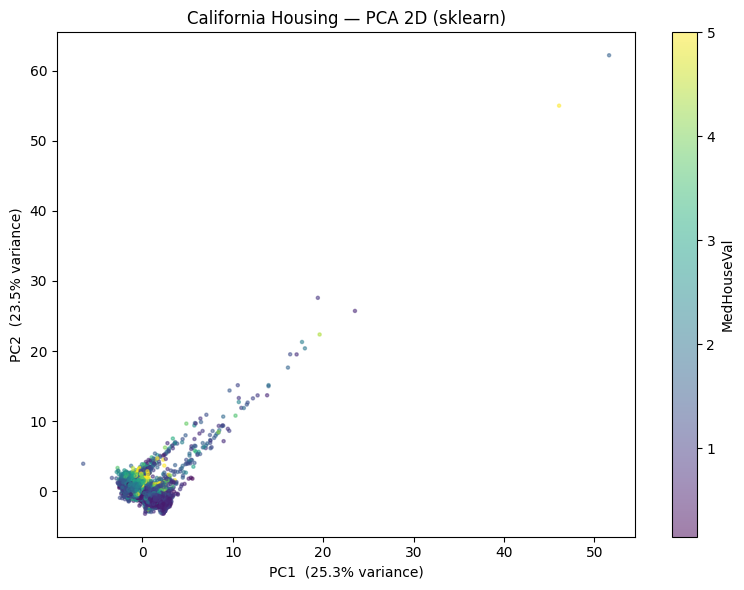

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc, ax=ax, label='MedHouseVal')
ax.set_xlabel(f'PC1  ({evr[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({evr[1]*100:.1f}% variance)')
ax.set_title('California Housing — PCA 2D (sklearn)')
plt.tight_layout(); plt.show()

## 6. Loadings Heatmap — All PCs vs All Features

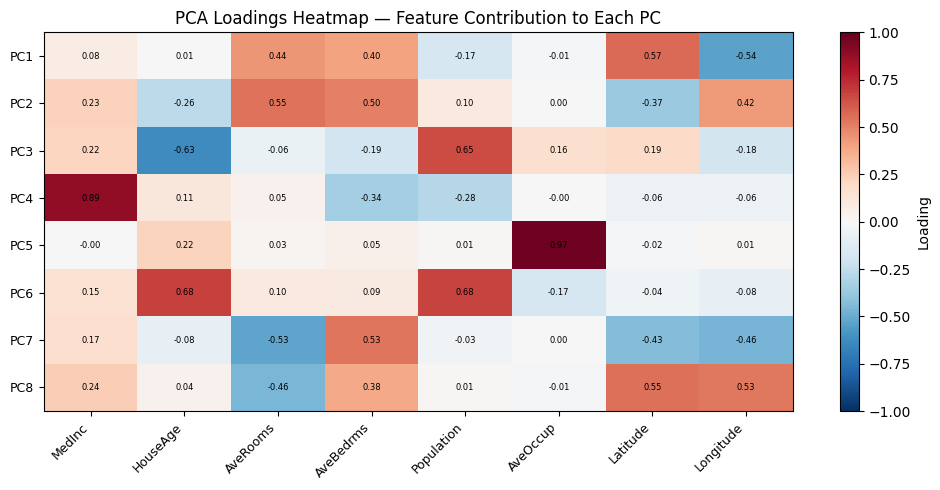

In [6]:
# Use the full PCA to get all loadings
loadings_all = pca_full.components_    # (p, p)  rows = PCs, cols = original features

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(loadings_all, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(p)); ax.set_xticklabels(features, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(p)); ax.set_yticklabels([f'PC{i+1}' for i in range(p)], fontsize=9)
plt.colorbar(im, ax=ax, label='Loading')
for i in range(p):
    for j in range(p):
        ax.text(j, i, f'{loadings_all[i,j]:.2f}', ha='center', va='center', fontsize=6)
ax.set_title('PCA Loadings Heatmap — Feature Contribution to Each PC')
plt.tight_layout(); plt.show()

## 7. Biplot (PC1 vs PC2)

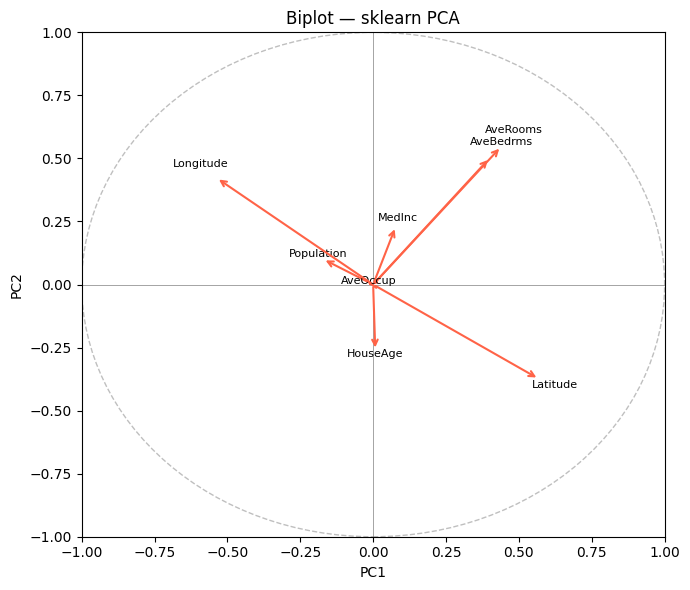

In [7]:
loadings_2d = pca_full.components_[:2].T    # (p, 2)

fig, ax = plt.subplots(figsize=(7, 6))
for i, feat in enumerate(features):
    ax.annotate('', xy=(loadings_2d[i, 0], loadings_2d[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
    ax.text(loadings_2d[i, 0]*1.1, loadings_2d[i, 1]*1.1, feat, fontsize=8, ha='center')

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
circle = plt.Circle((0,0), 1, fill=False, linestyle='--', color='grey', alpha=0.5)
ax.add_patch(circle)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Biplot — sklearn PCA')
plt.tight_layout(); plt.show()

## 8. Reconstruction & Inverse Transform

`inverse_transform` maps back from PCA space to the original (standardised) space.

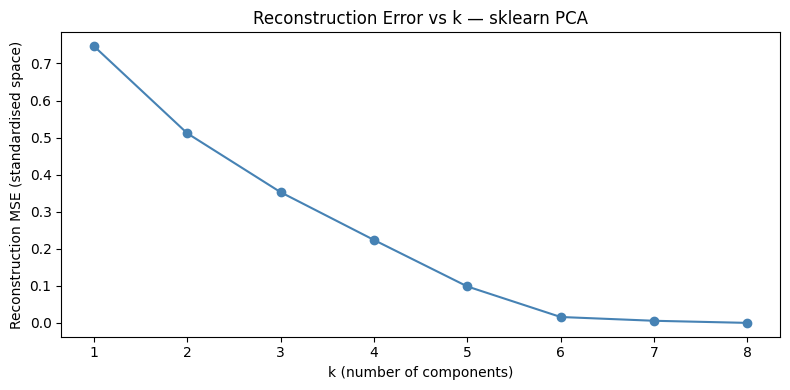

  k=1: MSE=0.746631  |  variance retained=25.34%
  k=2: MSE=0.511469  |  variance retained=48.85%
  k=3: MSE=0.352583  |  variance retained=64.74%
  k=4: MSE=0.223703  |  variance retained=77.63%
  k=5: MSE=0.098321  |  variance retained=90.17%
  k=6: MSE=0.015898  |  variance retained=98.41%
  k=7: MSE=0.005698  |  variance retained=99.43%
  k=8: MSE=0.000000  |  variance retained=100.00%


In [8]:
recon_errors = []
scaler       = pipeline_full['scaler']
X_scaled     = scaler.transform(X_raw)

for k in range(1, p + 1):
    pca_k_   = PCA(n_components=k, random_state=42).fit(X_scaled)
    X_proj   = pca_k_.transform(X_scaled)
    X_recon  = pca_k_.inverse_transform(X_proj)
    mse      = np.mean((X_scaled - X_recon) ** 2)
    recon_errors.append(mse)

plt.figure(figsize=(8, 4))
plt.plot(range(1, p + 1), recon_errors, marker='o', color='steelblue')
plt.xlabel('k (number of components)')
plt.ylabel('Reconstruction MSE (standardised space)')
plt.title('Reconstruction Error vs k — sklearn PCA')
plt.xticks(range(1, p + 1))
plt.tight_layout(); plt.show()

for k, err in enumerate(recon_errors, 1):
    print(f"  k={k}: MSE={err:.6f}  |  variance retained={cum[k-1]*100:.2f}%")

## 9. PCA as Preprocessing — Does Compression Help Linear Regression?

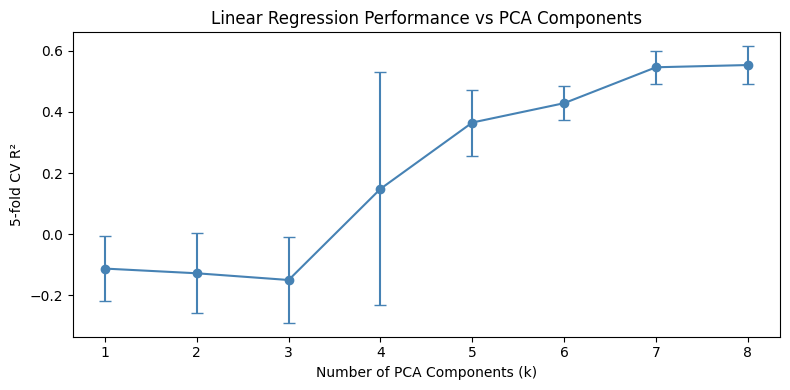

,R2_mean,R2_std
k,,
1,-0.1125,0.1074
2,-0.1279,0.1303
3,-0.1498,0.1402
4,0.1482,0.3806
5,0.3650,0.1078
6,0.4284,0.0556
7,0.5457,0.0534
8,0.5530,0.0617


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = []
for k in range(1, p + 1):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=k, random_state=42)),
        ('lr',     LinearRegression())
    ])
    scores = cross_val_score(pipe, X_raw, y, cv=5, scoring='r2')
    results.append({'k': k, 'R2_mean': scores.mean(), 'R2_std': scores.std()})

res_df = pd.DataFrame(results).set_index('k')

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(res_df.index, res_df['R2_mean'], yerr=res_df['R2_std'],
            marker='o', color='steelblue', capsize=4)
ax.set_xlabel('Number of PCA Components (k)')
ax.set_ylabel('5-fold CV R²')
ax.set_title('Linear Regression Performance vs PCA Components')
ax.set_xticks(res_df.index)
plt.tight_layout(); plt.show()
res_df.round(4)

## 10. Save Pipeline to `../Models/`

In [10]:
# Save the full PCA pipeline (all components) — caller can choose k at inference time
save_path = '../Models/pca_sklearn.joblib'
joblib.dump(pipeline_full, save_path)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/pca_sklearn.joblib  (2.6 KB)


## 11. Reload & Verify

In [11]:
pipeline_loaded = joblib.load('../Models/pca_sklearn.joblib')
pca_loaded      = pipeline_loaded['pca']

print(f"Components shape : {pca_loaded.components_.shape}")
print(f"Explained var    : {(pca_loaded.explained_variance_ratio_ * 100).round(2).tolist()}")

X_check = pipeline_loaded.transform(X_raw)
print(f"Transform check  : {X_raw.shape} → {X_check.shape}")

Components shape : (8, 8)
Explained var    : [25.34, 23.52, 15.89, 12.89, 12.54, 8.24, 1.02, 0.57]
Transform check  : (20640, 8) → (20640, 8)
